# Topic modeling

## 0. Libraries import

In [1]:
import pandas as pd
import numpy as np
import ast
import gensim
import gensim.corpora as corpora
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
import string 
import re
import bertopic
import sentence_transformers
import hdbscan

In [2]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from collections import Counter
from gensim.models import CoherenceModel
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN

## 1. Data import

In [3]:
DATA_PATH = "Kickstarter_filtered.csv"
df = pd.read_csv(DATA_PATH, index_col = 0, engine = "python")
df['lemmatized_filtered'] = df['lemmatized_filtered'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
print(df.shape)
df.head()

(7354, 14)


,title,description,pledged,goal,currency,video,category,reached,status,duration,description_processed,pos_tagged,lemmatized,lemmatized_filtered
url,,,,,,,,,,,,,,
https://www.kickstarter.com/projects/thetruthbook/the-life-network,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,48000.0,USD,1,Film & Video,148.172917,1,30,"['problem', 'much', 'entertainment', 'today', ...","[('problem', 'NN'), ('much', 'JJ'), ('entertai...","['problem', 'much', 'entertainment', 'today', ...","[problem, entertainment, today, push, unholy, ..."
https://www.kickstarter.com/projects/99625582/study-abroad-trip-of-a-lifetime,NaN,Millions of American college students have stu...,65318.0,61500.0,USD,1,Film & Video,106.208130,1,41,"['millions', 'american', 'college', 'students'...","[('millions', 'NNS'), ('american', 'JJ'), ('co...","['million', 'american', 'college', 'student', ...","[million, american, college, student, study, a..."
https://www.kickstarter.com/projects/distortreality/cartoon-network-alphabet-pins,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,8000.0,USD,1,Film & Video,5.775000,0,45,"['full', 'set', 'launching', 'set', 'show', 'l...","[('full', 'JJ'), ('set', 'NN'), ('launching', ...","['full', 'set', 'launch', 'set', 'show', 'love...","[full, launch, early, cartoon, network, type, ..."
https://www.kickstarter.com/projects/jordym/the-balloon-a-short-film,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,15000.0,USD,1,Film & Video,34.246667,0,60,"['sleepy', 'summer', 'afternoon', 'stared', 'v...","[('sleepy', 'NN'), ('summer', 'NN'), ('afterno...","['sleepy', 'summer', 'afternoon', 'star', 'voi...","[sleepy, summer, afternoon, star, void, float,..."
https://www.kickstarter.com/projects/trans-movie/something-you-should-know-about-me-a-feature-film,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50000.0,USD,1,Film & Video,101.280000,1,30,"['hours', 'pledge', 'matching', 'amazing', 'ne...","[('hours', 'NNS'), ('pledge', 'VBP'), ('matchi...","['hour', 'pledge', 'match', 'amaze', 'news', '...","[hour, pledge, match, amaze, news, generous, b..."


## 2. Topic modeling with Latent Dirichlet Analysis (LDA) for Film & Video category

### 2.1 Bag of Words creation

In [ ]:
df_film = df[df['category'] == 'Film & Video']
texts_film = df_film['lemmatized_filtered'].tolist()
dictionary_film = Dictionary(texts_film)
corpus_film = [dictionary_film.doc2bow(text) for text in texts_film]

print("Number of words in the dictionary:", len(dictionary_film))
print("Number of documents:", len(corpus_film))

Number of words in the dictionary: 18566
Number of documents: 2011


### 2.2 Coherence scores

#### Coherence scores computation

In [ ]:
topic_range = range(2, 6)

coherence_values = []
lda_models = []

for k in topic_range:
    lda_model = LdaMulticore(
        corpus = corpus_film,
        id2word = dictionary_film,
        num_topics = k,
        passes = 10,
        workers = 2,
        random_state = 11
    )

    # Coherence UMass
    coherence_umass = CoherenceModel(
        model = lda_model,
        corpus = corpus_film,
        dictionary = dictionary_film,
        coherence = 'u_mass'
    ).get_coherence()

    # Coherence C_V
    coherence_cv = CoherenceModel(
        model = lda_model,
        texts = texts_film,
        dictionary = dictionary_film,
        coherence = 'c_v'
    ).get_coherence()

    # Coherence NPMI
    coherence_npmi = CoherenceModel(
        model = lda_model,
        texts = texts_film,
        dictionary = dictionary_film,
        coherence = 'c_npmi'
    ).get_coherence()

    coherence_values.append((k, coherence_umass, coherence_cv, coherence_npmi))
    lda_models.append(lda_model)

    print(f"k = {k} | UMass = {coherence_umass:.4f} | C_V = {coherence_cv:.4f} | NPMI = {coherence_npmi:.4f}")

k = 2 | UMass = -0.7794 | C_V = 0.3571 | NPMI = 0.0009
k = 3 | UMass = -0.8309 | C_V = 0.3654 | NPMI = 0.0068
k = 4 | UMass = -0.8283 | C_V = 0.3616 | NPMI = 0.0039
k = 5 | UMass = -0.8759 | C_V = 0.3474 | NPMI = 0.0032


#### Coherence scores visualization

   num_topics    u_mass       c_v      npmi
0           2 -0.779361  0.357117  0.000942
1           3 -0.830868  0.365362  0.006784
2           4 -0.828311  0.361569  0.003867
3           5 -0.875884  0.347440  0.003242


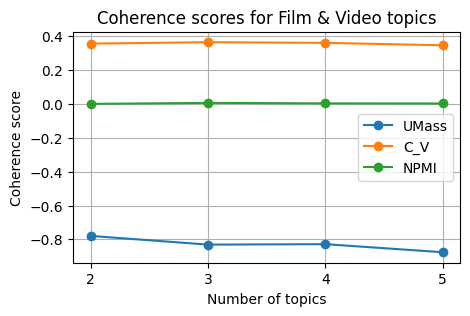

In [ ]:
scores = pd.DataFrame(
    coherence_values,
    columns = ["num_topics", "u_mass", "c_v", "npmi"]
)
print(scores)

plt.figure(figsize = (5, 3))

plt.plot(scores["num_topics"], scores["u_mass"], marker = "o", label = "UMass")
plt.plot(scores["num_topics"], scores["c_v"], marker = "o", label = "C_V")
plt.plot(scores["num_topics"], scores["npmi"], marker = "o", label = "NPMI")

plt.xlabel("Number of topics")
plt.ylabel("Coherence score")
plt.title("Coherence scores for Film & Video topics")
plt.xticks(scores["num_topics"])
plt.legend()
plt.grid(True)
plt.show()

### 2.3 Identification of the main topics

#### Latent Dirichlet Allocation (LDA)

In [ ]:
num_topics = 3

model_film = LdaMulticore(
    corpus=  corpus_film,
    id2word = dictionary_film,
    num_topics = num_topics,
    passes = 10,
    workers = 2,
    random_state = 11
)

topic_corpus_film = model_film[corpus_film]

print("\nTopic distribution of the first Film & Video document:")
print(topic_corpus_film[0])

print("\nTop 20 words for each topic in 'Film & Video':")
for i, topic in model_film.print_topics(num_words = 20):
    print(f"\nTopic {i}:")
    print(topic)


Topic distribution of the first Film & Video document:
[(0, np.float32(0.13480599)), (1, np.float32(0.037329577)), (2, np.float32(0.82786447))]

Top 20 words for each topic in 'Film & Video':

Topic 0:
0.025*"film" + 0.004*"director" + 0.004*"short" + 0.004*"festival" + 0.004*"producer" + 0.003*"art" + 0.003*"family" + 0.003*"community" + 0.003*"documentary" + 0.003*"crew" + 0.002*"filmmaker" + 0.002*"produce" + 0.002*"award" + 0.002*"cast" + 0.002*"tell" + 0.002*"school" + 0.002*"day" + 0.002*"woman" + 0.002*"black" + 0.002*"artist"

Topic 1:
0.026*"film" + 0.006*"movie" + 0.005*"festival" + 0.004*"short" + 0.003*"producer" + 0.003*"director" + 0.003*"art" + 0.003*"cast" + 0.003*"write" + 0.003*"music" + 0.002*"crew" + 0.002*"video" + 0.002*"day" + 0.002*"produce" + 0.002*"character" + 0.002*"great" + 0.002*"series" + 0.002*"right" + 0.002*"actor" + 0.002*"thing"

Topic 2:
0.013*"film" + 0.006*"episode" + 0.005*"series" + 0.004*"character" + 0.004*"music" + 0.004*"sound" + 0.004*"ani

##### Interpretation of topic descriptions

In [ ]:
topic_sep = re.compile(r"0\.[0-9]{3}\*")

model_topics = [
    (topic_no, re.sub(topic_sep, "", model_topic).split(' + '))
    for topic_no, model_topic in model_film.print_topics(num_topics = num_topics, num_words = 20)
]

descriptors = []

print("Readable topic descriptors:\n")
for i, words in model_topics:
    clean_words = [w.replace('"', '').strip() for w in words]
    print(f"Topic {i}: {', '.join(clean_words)}")
    descriptors.append(", ".join(clean_words[:6]))

print("\nShort descriptors list:")
print(descriptors)

Readable topic descriptors:

Topic 0: film, director, short, festival, producer, art, family, community, documentary, crew, filmmaker, produce, award, cast, tell, school, day, woman, black, artist
Topic 1: film, movie, festival, short, producer, director, art, cast, write, music, crew, video, day, produce, character, great, series, right, actor, thing
Topic 2: film, episode, series, character, music, sound, animation, video, artist, director, season, crew, cast, budget, actor, producer, produce, pilot, voice, art

Short descriptors list:
['film, director, short, festival, producer, art', 'film, movie, festival, short, producer, director', 'film, episode, series, character, music, sound']


#### 4. Topic quality measurement

In [ ]:
# number of words for each topic
num_words = 15

# extraction of top words for each topic
topic_words = [
    re.sub(topic_sep, "", model_topic).split(' + ')
    for topic_no, model_topic in model_film.print_topics(
        num_topics = num_topics,
        num_words = num_words
    )
]

# text cleaning
topic_words = [
    [w.replace('"', '').strip() for w in topic]
    for topic in topic_words
]

# set of unique words
unique_words = set()
for topic in topic_words:
    unique_words.update(topic[:num_words])

# topic diversity
td = len(unique_words) / (num_words * len(topic_words))

print(
    f"Topic Diversity (top-{num_words} words): {td:.4f} "
    f"[unique words = {len(unique_words)}, total words = {num_words * len(topic_words)}]"
)

Topic Diversity (top-15 words): 0.6444 [unique words = 29, total words = 45]


#### 5. Dominant topic assignment to each document

In [ ]:
dominant_topics = []
dominant_topic_probs = []

for doc_topics in topic_corpus_film:
    dominant_topic, dominant_prob = max(doc_topics, key = lambda x: x[1])
    dominant_topics.append(dominant_topic)
    dominant_topic_probs.append(dominant_prob)

# creation of a dataframe with the results
df_topics_film = pd.DataFrame({
    "dominant_topic": dominant_topics,
    "dominant_topic_prob": dominant_topic_probs
})

topic_labels = {i: descriptors[i] for i in range(len(descriptors))}
df_topics_film["topic_label"] = df_topics_film["dominant_topic"].map(topic_labels)

print(df_topics_film.head())

   dominant_topic  dominant_topic_prob  \
0               2             0.828205   
1               0             0.935508   
2               1             0.906512   
3               0             0.997890   
4               0             0.644082   

                                        topic_label  
0    film, episode, series, character, music, sound  
1    film, director, short, festival, producer, art  
2  film, movie, festival, short, producer, director  
3    film, director, short, festival, producer, art  
4    film, director, short, festival, producer, art  


#### 6. Relationship between topics and project success

In [ ]:
# Assigning dominant topic to each document
doc_topics = []

for doc in corpus_film:
    topics = model_film.get_document_topics(doc)
    dominant_topic = max(topics, key = lambda x: x[1])[0]
    doc_topics.append(dominant_topic)

# Creation of Film & Video dataframe
df_film = df[df["category"] == "Film & Video"].copy()
df_film["topic"] = doc_topics

# Relationship between topics and project success
summary = df_film.groupby("topic").agg({
    "status": ["mean", "count"]
})

summary.columns = ["success_rate", "num_projects"]
summary = summary.reset_index()
summary["topic_label"] = summary["topic"].map(topic_labels)

print("\nSummary by topic:")
print(summary)


Summary by topic:
   topic  success_rate  num_projects  \
0      0      0.665826           793   
1      1      0.633333           780   
2      2      0.563927           438   

                                        topic_label  
0    film, director, short, festival, producer, art  
1  film, movie, festival, short, producer, director  
2    film, episode, series, character, music, sound  


### 2.7 Topic probabilities for all documents

In [ ]:
# transforming the topic distribution in a matrix
topic_matrix = []

for doc_topics in topic_corpus_film:
    row = {topic_id: prob for topic_id, prob in doc_topics}
    topic_matrix.append(row)

topic_distros = pd.DataFrame(topic_matrix)

topic_distros.columns = [topic_labels[i] for i in topic_distros.columns]
df_film = df[df["category"] == "Film & Video"].copy().reset_index(drop = True)
topic_distros["category"] = df_film["category"].values
topic_distros["status"] = df_film["status"].values

if "text" in df_film.columns:
    topic_distros["document"] = df_film["text"].values
elif "blurb" in df_film.columns:
    topic_distros["document"] = df_film["blurb"].values
elif "name" in df_film.columns:
    topic_distros["document"] = df_film["name"].values

print(topic_distros.head())

   film, director, short, festival, producer, art  \
0                                        0.135123   
1                                        0.935661   
2                                             NaN   
3                                        0.997891   
4                                        0.644084   

   film, movie, festival, short, producer, director  \
0                                          0.036111   
1                                          0.062697   
2                                          0.907153   
3                                               NaN   
4                                          0.232321   

   film, episode, series, character, music, sound      category  status  
0                                        0.828766  Film & Video       1  
1                                             NaN  Film & Video       1  
2                                        0.091045  Film & Video       0  
3                                             NaN  Fil

In [ ]:
# ============================================================
# 8. Predicted topic for each document
# ============================================================

topic_columns = list(topic_labels.values())

topic_distros["predicted_topic"] = topic_distros[topic_columns].idxmax(axis=1)

print(topic_distros.head())

   film, director, short, festival, producer, art  \
0                                        0.135123   
1                                        0.935661   
2                                             NaN   
3                                        0.997891   
4                                        0.644084   

   film, movie, festival, short, producer, director  \
0                                          0.036111   
1                                          0.062697   
2                                          0.907153   
3                                               NaN   
4                                          0.232321   

   film, episode, series, character, music, sound      category  status  \
0                                        0.828766  Film & Video       1   
1                                             NaN  Film & Video       1   
2                                        0.091045  Film & Video       0   
3                                             NaN 

In [ ]:
# ============================================================
# 9. Examining individual documents
# ============================================================

# scegli un topic da ispezionare
topic_id = 0
chosen_topic = topic_labels[topic_id]

ds_df = topic_distros[topic_distros["predicted_topic"] == chosen_topic]

print("Topic scelto:", chosen_topic)
print("Numero documenti:", len(ds_df))

Topic scelto: film, director, short, festival, producer, art
Numero documenti: 793


In [ ]:
# ============================================================
# 10. Most representative documents for a topic
# ============================================================

topic_id = 0
chosen_topic = topic_labels[topic_id]

top_examples = topic_distros.sort_values(by=chosen_topic, ascending=False)

print("Topic scelto:", chosen_topic)

for i in range(5):
    print(f"\n--- Documento {i+1} ---")
    print("Probabilità topic:", top_examples[chosen_topic].iloc[i])
    print(top_examples["document"].iloc[i])

Topic scelto: film, director, short, festival, producer, art

--- Documento 1 ---
Probabilità topic: 0.999313235282898


KeyError: 'document'

#### 7. Logistic regression

In [ ]:
X = pd.get_dummies(df_film['topic'], prefix='topic', drop_first=True)
y = df_film['status']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

print(coefficients)

   feature  coefficient
0  topic_1    -0.523610
1  topic_2    -0.113334


## 3. BERTopic

### 3.1 Text processing

In [6]:
# Filtering dataset on Film & Video category
df_film = df[df["category"] == "Film & Video"].copy().reset_index(drop = True)
print("Number of Film & Video projects:", len(df_film))

# Preparing the text
docs_film = (
    df_film["title"].fillna("") + ". " +
    df_film["description_processed"].fillna("")
).astype(str).tolist()

# Cleaning the text 
vectorizer_model = CountVectorizer(
    stop_words = "english",
    min_df = 5,
    max_df = 0.90
)
vectorizer_model.set_params(
    stop_words = list(vectorizer_model.get_stop_words()) 
)
hdbscan_model = HDBSCAN(
    min_cluster_size = 15,
    min_samples = 5,
    metric = "euclidean",
    prediction_data = True
)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
representation_model = KeyBERTInspired()

Number of Film & Video projects: 2011


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

### 3.2 

In [ ]:



# 4. Train BERTopic
topic_model_film = BERTopic(
    embedding_model = embedding_model,
    representation_model = representation_model,
    vectorizer_model = vectorizer_model,
    hdbscan_model = hdbscan_model,
    calculate_probabilities = True,
    verbose = True,
    min_topic_size = 15
)
topics_film, probs_film = topic_model_film.fit_transform(docs_film)

# 5. Identifying the different topics
topic_info_film = topic_model_film.get_topic_info()
valid_topics_film = sorted([t for t in set(topics_film) if t != -1])
topic_labels_film = {}
for t in valid_topics_film:
    words = topic_model_film.get_topic(t)
    topic_labels_film[t] = ", ".join([w for w, _ in words[:4]])
topic_labels_film[-1] = "outlier"
print("\nTopic labels:\n")
print(topic_labels_film)

# 6. Adding the topics to dataframe
df_film["topic"] = topics_film
df_film["topic_label"] = df_film["topic"].map(topic_labels_film)
topic_probs = []
for i, t in enumerate(topics_film):
    if t == -1:
        topic_probs.append(None)
    else:
        topic_probs.append(probs_film[i][t])
df_film["topic_prob"] = topic_probs

print("\nAssigned topics:\n")
print(df_film[["topic", "topic_label", "topic_prob"]].head())

# ------------------------------------------------------------
# 8. Topic summary
# ------------------------------------------------------------

summary_topics_film = (
    df_film.groupby(["topic", "topic_label"])
    .size()
    .reset_index(name="num_documents")
    .sort_values("num_documents", ascending=False)
)

print("\nTopic summary:\n")
print(summary_topics_film)

# ------------------------------------------------------------
# 9. Success rate by topic
# ------------------------------------------------------------

summary_success_film = (
    df_film.groupby(["topic", "topic_label"])
    .agg(
        success_rate=("status", "mean"),
        num_projects=("status", "count")
    )
    .reset_index()
    .sort_values("num_projects", ascending=False)
)

print("\nSuccess rate by topic:\n")
print(summary_success_film)

Number of Film & Video projects: 2011


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-05-02 21:48:03,189 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-05-02 21:48:13,619 - BERTopic - Embedding - Completed ✓
2026-05-02 21:48:13,620 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-02 21:48:18,824 - BERTopic - Dimensionality - Completed ✓
2026-05-02 21:48:18,824 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-02 21:48:19,190 - BERTopic - Cluster - Completed ✓
2026-05-02 21:48:19,192 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-02 21:48:20,622 - BERTopic - Representation - Completed ✓



Topic info:

    Topic  Count                                          Name  \
0      -1    858      -1_numerous_adventure_disney_communities   
1       0    265             0_lost_sundance_communities_books   
2       1     69            1_cinemas_cultural_levels_theaters   
3       2     65               2_words_writers_letters_studios   
4       3     42       3_storyboard_communities_studios_fierce   
5       4     41                 4_cartoon_english_forth_drama   
6       5     41                  5_lost_sundance_cult_studios   
7       6     39         6_sundance_echoes_lost_cinematography   
8       7     38             7_lost_communities_ones_sanctuary   
9       8     37                8_genre_studios_fest_adventure   
10      9     37       9_bible_adventures_adventure_paranormal   
11     10     34              10_adventure_comics_wolf_kingdom   
12     11     34                       11_vox_teens_speech_act   
13     12     33      12_tales_adventure_adventures_storyboard